# Test conversion of file to npz
## We also included there violin plots for comparing conditions in this test

In [1]:
from metamers.eeg.ssvep2python import transform1Set, load_ssvep_npz
import os
srcFolder = "/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/eegExp/results/shareDarren"
fname    = "MET004TESTBLUEBlueTest.mat"
targetFoder = "/home/zevaz/projects/metamers/eeg/ssvepBLUETEST"
transform1Set(mat_root=srcFolder, fname= fname, npz_root=targetFoder)

[convert] MET004TESTBLUEBlueTest.mat → /home/zevaz/projects/metamers/eeg/ssvepBLUETEST/MET004TESTBLUEBlueTest.npz
Saved fields:
['SSVEPs', 'SubID', 'baselineDIM', 'baselines', 'blueArray', 'blueFixed', 'blueShiftArray', 'conditions', 'redFixed', 'ssvepDIM', 'yellowFixed']
Conversion complete.


## Load npz file

In [2]:
npz_path = os.path.join(targetFoder, fname.replace(".mat", ".npz"))
ssvep =load_ssvep_npz(npz_path)
print(ssvep)


{'SSVEPs': array([[0.59221355, 1.29631329, 1.14592224, 1.11215911, 0.80663756,
        0.56351485, 1.53436293, 1.32157663, 0.78181957, 0.58849293],
       [0.73363667, 1.03171981, 0.93591121, 0.89834169, 1.04124264,
        0.51986126, 1.51665896, 1.55760227, 0.61331721, 0.65235223],
       [0.74065524, 0.93288098, 0.91144572, 0.81822214, 0.83722157,
        0.64126778, 1.32360212, 1.57122372, 0.53923615, 0.79261784],
       [0.62792415, 1.03124244, 1.24052257, 1.09357603, 0.8780557 ,
        0.6056996 , 1.43359479, 1.53889218, 0.62232661, 0.67615227],
       [0.71654559, 1.02647473, 1.04761737, 0.93619631, 0.85840745,
        0.73727134, 1.31600229, 1.49405134, 0.53449268, 0.56206112],
       [0.73546242, 1.16153001, 0.95078086, 0.73660359, 0.63807289,
        0.58232969, 1.43803246, 1.34877815, 0.7066597 , 0.59512648],
       [0.64160001, 1.27695994, 1.20548173, 0.71568217, 0.71134298,
        0.67342874, 1.56272727, 1.53549855, 0.6347771 , 0.70238667],
       [0.8187772 , 1.21066379

In [3]:
print(type(ssvep))
print(isinstance(ssvep, dict))
print(ssvep.keys())
# inspect the elements
for k in ssvep.keys():
    print(k, type(ssvep[k]), getattr(ssvep[k],'shape',None))

<class 'dict'>
True
dict_keys(['SSVEPs', 'SubID', 'baselineDIM', 'baselines', 'blueArray', 'blueFixed', 'blueShiftArray', 'conditions', 'redFixed', 'ssvepDIM', 'yellowFixed'])
SSVEPs <class 'numpy.ndarray'> (20, 10)
SubID <class 'numpy.ndarray'> (1,)
baselineDIM <class 'numpy.ndarray'> (1, 1)
baselines <class 'numpy.ndarray'> (3, 10)
blueArray <class 'numpy.ndarray'> (1, 20)
blueFixed <class 'numpy.ndarray'> (1, 1)
blueShiftArray <class 'numpy.ndarray'> (1, 20)
conditions <class 'numpy.ndarray'> (1, 10)
redFixed <class 'numpy.ndarray'> (1, 1)
ssvepDIM <class 'numpy.ndarray'> (1, 1)
yellowFixed <class 'numpy.ndarray'> (1, 1)


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd

def convert_to_dataframe(data = ssvep):
    ssvep_vals = data["SSVEPs"]        # shape (20, 10)
    baseline_vals = data["baselines"]  # shape (3, 10)
    raw_conditions = [str(c) for c in data["conditions"].flatten()]
    conditions = [ c.strip("[]'")  for c in raw_conditions]
    # Build long-form dataframe
    rows = []

    # Add SSVEP rows
    for cond_idx, cond in enumerate(conditions):
        for v in ssvep_vals[:, cond_idx]:
            rows.append({"Condition": cond, "Value": v, "Type": "SSVEP"})

    # Add baseline rows
    for cond_idx, cond in enumerate(conditions):
        for v in baseline_vals[:, cond_idx]:
            rows.append({"Condition": cond, "Value": v, "Type": "Baseline"})

    df = pd.DataFrame(rows)
    return df


def plot1variable(data , var= "Value", title=""):

    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=data,
        x="Condition",
        y=var,
        hue="Type",
        split=True,
        inner="quartile",
        palette=["#1f77b4", "#ff7f0e"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plotFilterVsnoFilter(dataFiltered, dataNofiltered,var="Value", mode = "All" ,title="SSVEP Amplitudes: Filter vs NoFilter per Condition"):
    # correspondence dictionary
    filter_map = {
    "BFi": "B",
    "BYFi": "BY",
    "BRFi": "BR",
    "BFFi": "BF",
    "BSFi": "BS"
    }

    # Add a base condition for no filteredData
    dataNofiltered = dataNofiltered.copy()
    dataNofiltered["BaseCondition"] = dataNofiltered["Condition"]  # already base
    dataNofiltered["FilterType"] = "NoFilter"

    # Add a base condition for Filtered data
    dataFiltered = dataFiltered.copy()
    dataFiltered["BaseCondition"] = dataFiltered["Condition"].map(filter_map)
    dataFiltered["FilterType"] = "Filter"

    # combine the patched datasets
    dfCompare = pd.concat([dataNofiltered, dataFiltered], ignore_index=True)

        # -------------------------
    # Apply mode filtering here
    # -------------------------
    if mode.lower() == "ssvep":
        dfCompare = dfCompare[dfCompare["Type"] == "SSVEP"]
    elif mode.lower() == "baseline":
        dfCompare = dfCompare[dfCompare["Type"] == "Baseline"]
    # mode="all" → no filtering
    
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=dfCompare,
        x="BaseCondition",
        y=var,
        hue="FilterType",
        split=True,
        inner="quartile",
        palette=["#1f77b4", "#ff7f0e"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()



    Condition     Value      Type
0           B  0.592214     SSVEP
1           B  0.733637     SSVEP
2           B  0.740655     SSVEP
3           B  0.627924     SSVEP
4           B  0.716546     SSVEP
..        ...       ...       ...
225      BFFi  0.549401  Baseline
226      BFFi  0.674089  Baseline
227      BSFi  0.561090  Baseline
228      BSFi  0.560206  Baseline
229      BSFi  0.790275  Baseline

[230 rows x 3 columns]


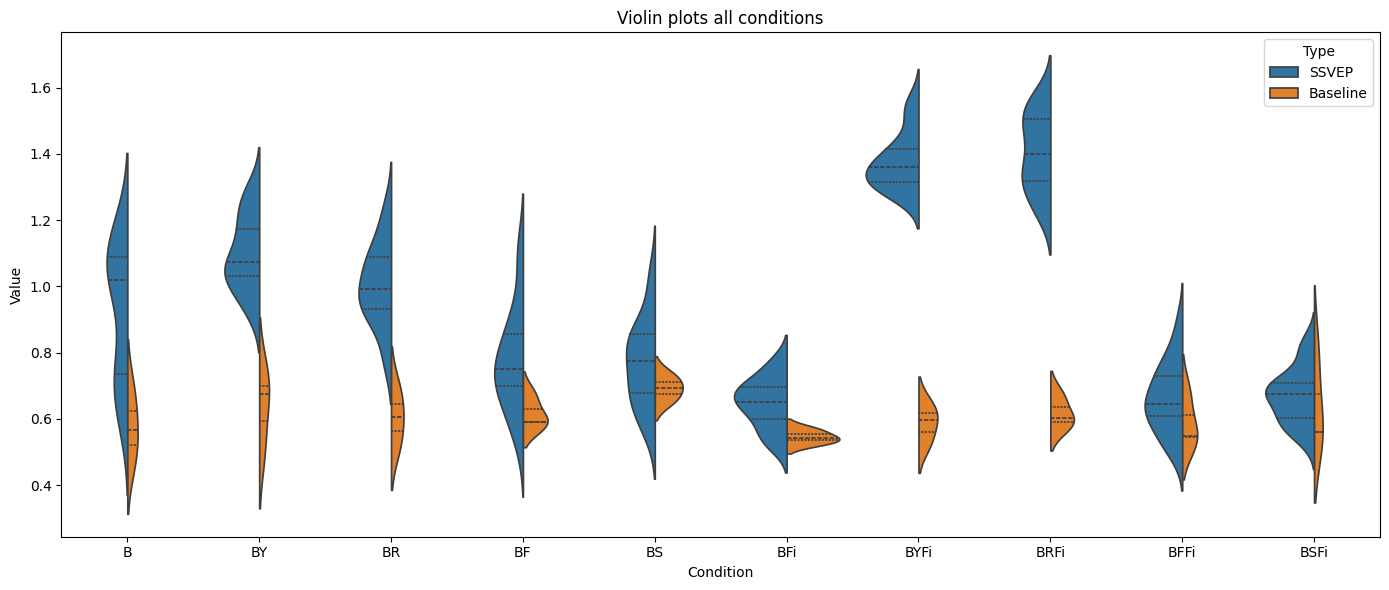

In [4]:
df = convert_to_dataframe(ssvep)
print(df)
plot1variable(df,"Value","Violin plots all conditions")

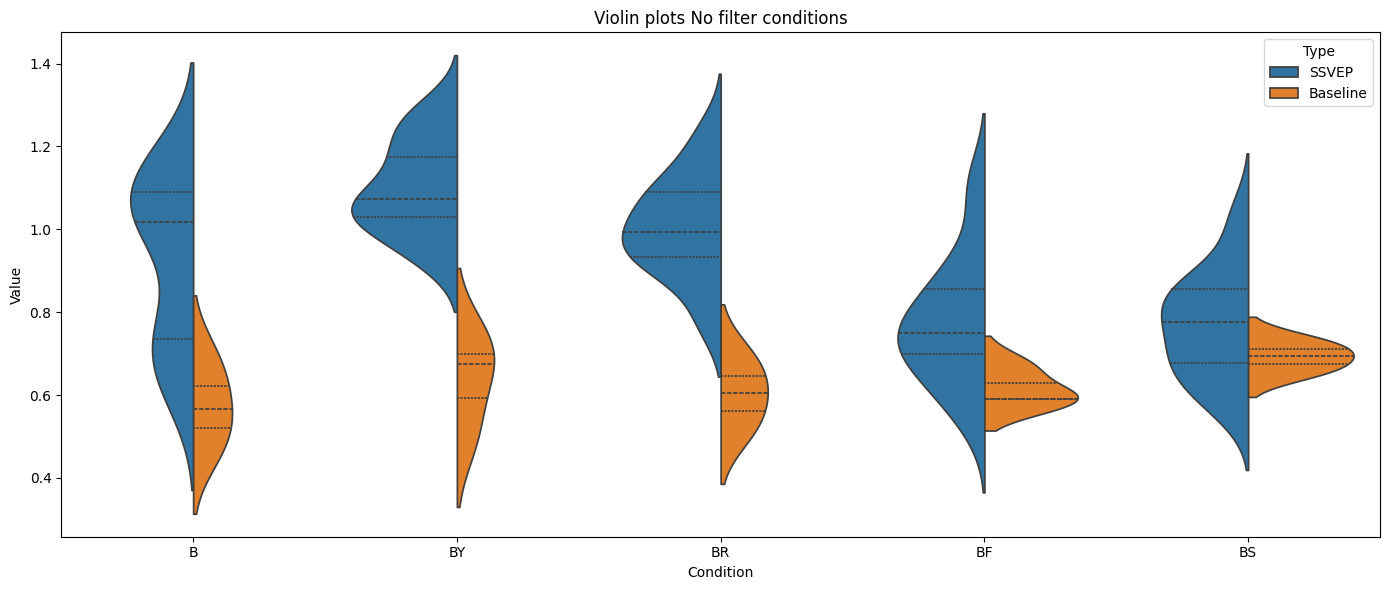

In [5]:
dfnoFilt = df[df["Condition"].isin(['B', 'BY', 'BR', 'BF', 'BS'])]
plot1variable(dfnoFilt,"Value","Violin plots No filter conditions")

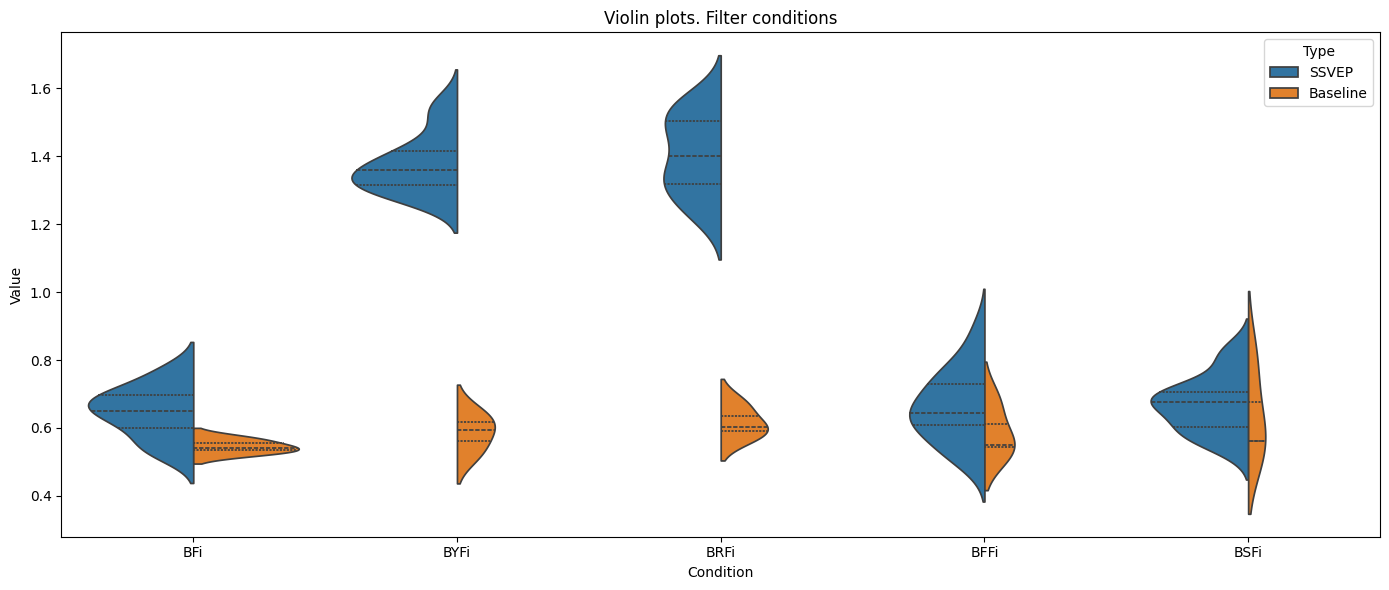

In [6]:
dfFilt = df[df["Condition"].isin(['BFi', 'BYFi', 'BRFi', 'BFFi', 'BSFi'])]
plot1variable(dfFilt,"Value","Violin plots. Filter conditions")

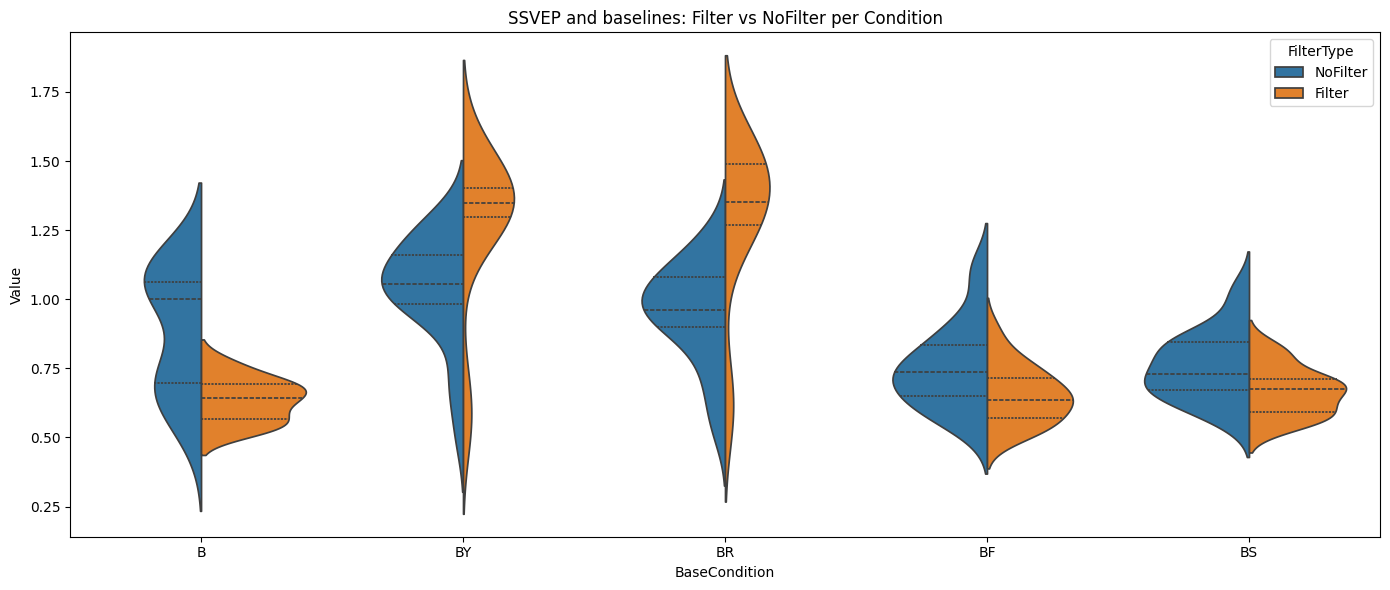

In [7]:
plotFilterVsnoFilter(dfFilt, dfnoFilt,var="Value",mode="All",title="SSVEP and baselines: Filter vs NoFilter per Condition")

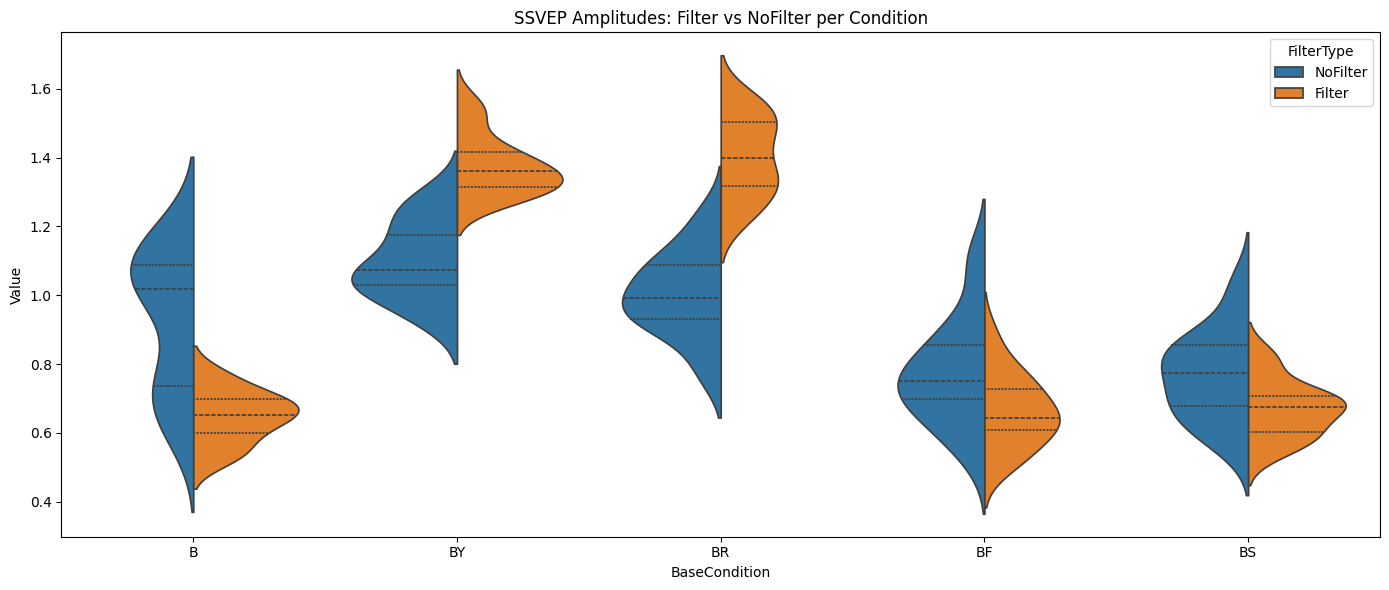

In [8]:
plotFilterVsnoFilter(dfFilt, dfnoFilt,var="Value",mode="ssvep" ,title="SSVEP Amplitudes: Filter vs NoFilter per Condition")

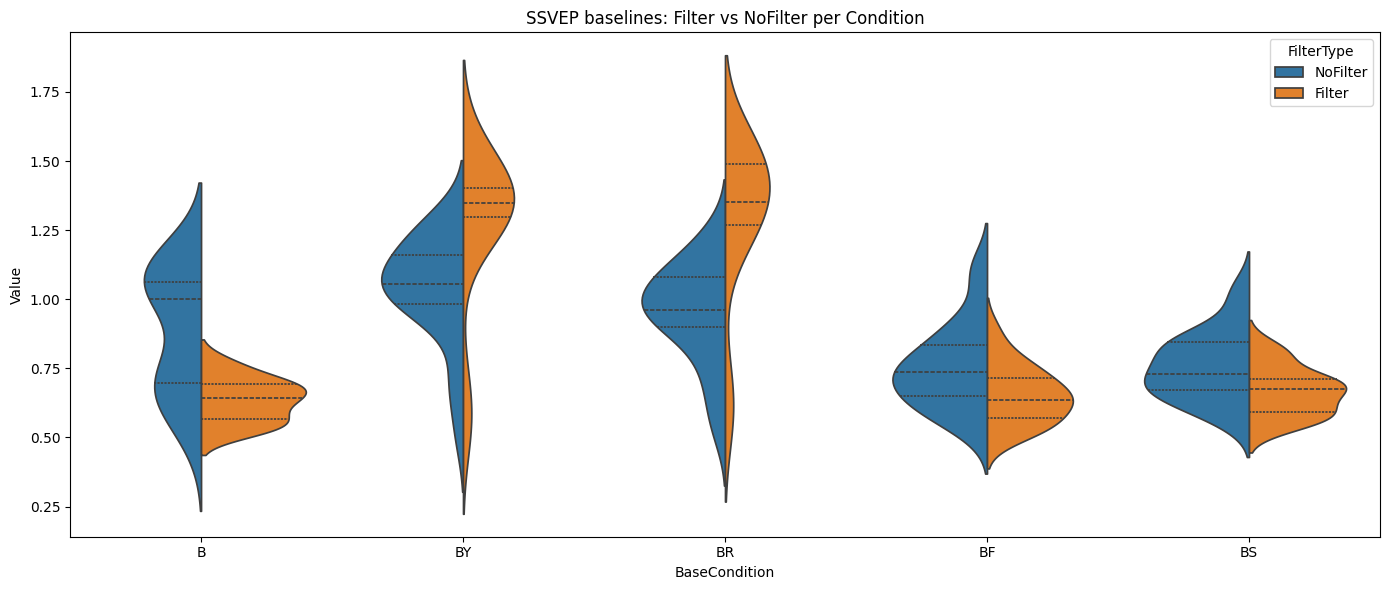

In [9]:
plotFilterVsnoFilter(dfFilt, dfnoFilt,var="Value",mode="baselines" ,title="SSVEP baselines: Filter vs NoFilter per Condition")